In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pathlib
import pickle
import sys
import os
import yaml

from pathlib import Path

sys.path.insert(0, str(Path("..").resolve() / "eitprocessing"))
from eitprocessing.features.rate_detection import RateDetection
from eitprocessing.plotting.rate_detection import RateDetectionPlotting

sys.path.append(r"../src")
from preprocessing import butter_bandpass_filter
from loading import (
    load_synchronized_sequence,
    load_synchronized_pes,
    load_synchronized_eit,
    get_window_mask,
    crop_eit_to_window,
)
from visualization import plot_ssa_overview, plot_cgo_analysis, plot_pes_segment

sys.path.append(r"../filter")
from SSA_HR import process_pes, rc_pair_overview_dataframe

sys.path.append(r"../config")
from dataset_config import get_dataset_window

→ Ruw tijdsvenster PES: 73030.75s–74823.99s


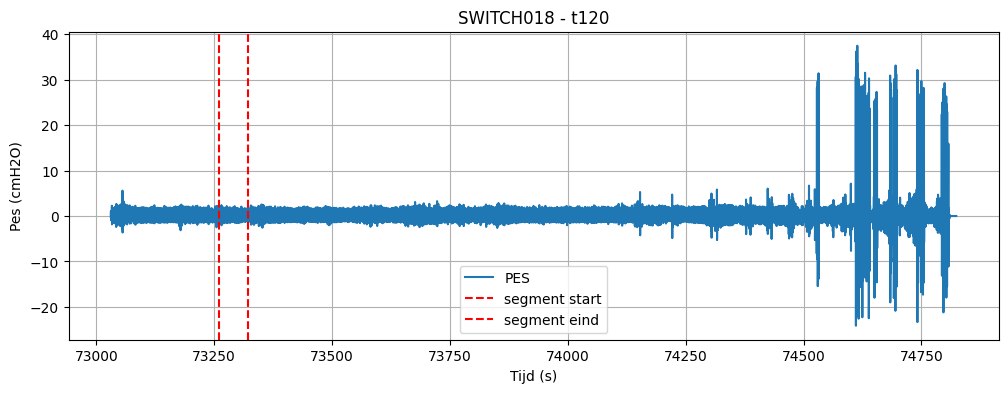

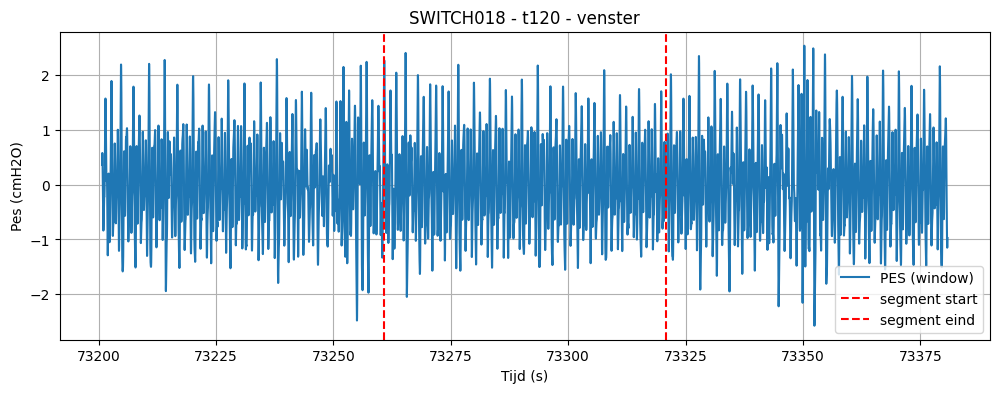

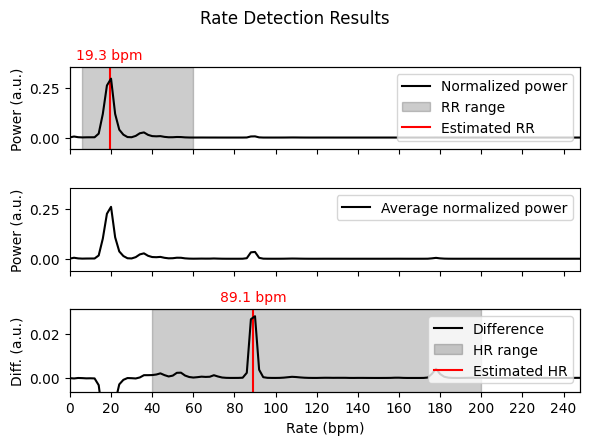

→ Patient: SWITCH018
→ Phase: t120
→ Tijdvenster PES: 73260.75s–73320.75s
→ Tijdvenster EIT: 73260.75s–73320.75s
→ RR (EIT): 19.32 bpm
→ HR (EIT): 89.11 bpm


In [ ]:
# ----------------
# Instellingen
# ----------------
patient = "018"   # 002, 004, 005, 006, 009, 010, 011, 012, 014, 015, 016, 017, 018
phase = "t120"     # preswitch, t0, t30, t60, t90, t120, t150, t180, t210
fs = 256
plot_margin = 60

sync_base = ... # Path naar gesynchronizeerde data


# ---------------------------------------
# Gesynchroniseerde data inladen
# ---------------------------------------
sequence = load_synchronized_sequence(sync_path)

time, pes = load_synchronized_pes(sequence)
eit_signal, eit_time = load_synchronized_eit(sequence)

print(f"→ Ruw tijdsvenster PES: {time[0]:.2f}s–{time[-1]:.2f}s")


# ------------------
# Tijdvenster bepalen
# ------------------
t_start, t_end = get_dataset_window(patient, phase)

# Dataset-window relatief maken aan starttijd van PES
t_start += time[0]
t_end += time[0]


# ------------------
# PES preprocessing
# ------------------
pes_filt = butter_bandpass_filter(pes, lowcut=0.67, highcut=4, fs=fs)

# ---------------
# PES vensters
# ---------------
pes_segment_mask = get_window_mask(time, t_start, t_end)
pes_plot_mask = get_window_mask(time, t_start - plot_margin, t_end + plot_margin)

time_window = time[pes_segment_mask]
pes_window = pes_filt[pes_segment_mask]

time_pes_plot = time[pes_plot_mask]
pes_plot = pes_filt[pes_plot_mask]


# ------------
# PES plotten
# ------------
plot_pes_segment(
    time=time,
    pes_filt=pes_filt,
    time_pes_plot=time_pes_plot,
    pes_plot=pes_plot,
    t_start=t_start,
    t_end=t_end,
    patient=patient,
    phase=phase,
)


# ---------------
# EIT venster
# ---------------
eit_window, start_idx, end_idx = crop_eit_to_window(
    eit_signal=eit_signal,
    t_start=t_start,
    t_end=t_end,
)


# -------------------
# HR en RR detectie
# -------------------
rd = RateDetection(subject_type="adult")
captures = {}

rr_eit, hr_eit = rd.apply(eit_window, captures=captures)

plotter = RateDetectionPlotting(rd)
fig = plotter.plot(**captures)
plt.show()


# --------
# Output
# --------
print(f"→ Patient: SWITCH{patient}")
print(f"→ Phase: {phase}")
print(f"→ Tijdvenster PES: {time_window[0]:.2f}s–{time_window[-1]:.2f}s")
print(f"→ Tijdvenster EIT: {eit_time[start_idx]:.2f}s–{eit_time[end_idx - 1]:.2f}s")
print(f"→ RR (EIT): {rr_eit * 60:.2f} bpm")
print(f"→ HR (EIT): {hr_eit * 60:.2f} bpm")

## Singular Spectrum Analysis

In [3]:
pes_bp, cgo, RCs, rc_pairs, chosen_pair, t_hr, hr, peaks, s, pair_scores, cgo_energy, pes_bp_energy, cgo_to_pesbp_ratio = process_pes(time_window, pes_window, fs)

## Reconstructed components visualisatie

In [4]:
df_rc_pairs = rc_pair_overview_dataframe(
    pair_scores=pair_scores,
    RCs=RCs,
    rc_pairs=rc_pairs,
    fs=fs,
    hr_eit=hr_eit,
)

display(df_rc_pairs)

,pair,cardiac_energy,respiratory_energy,score,contribution,f_dom_hz,f_target_hz,chosen_cgo,chosen_hr_eit
0,"(0, 1)",1.436800e+07,100.393547,1.436750e+07,1.169937,1.483237,1.485105,True,True
1,"(2, 3)",5.167716e+06,676809.366983,1.783669e+06,0.485573,0.899941,1.485105,False,False
2,"(6, 7)",1.773175e+06,497.177680,1.770689e+06,0.211178,2.966474,1.485105,False,False
3,"(4, 5)",1.522817e+06,93963.879093,1.052997e+06,0.549807,1.166591,1.485105,False,False
4,"(8, 9)",2.382497e+05,18200.966775,1.472449e+05,0.354059,1.766552,1.485105,False,False


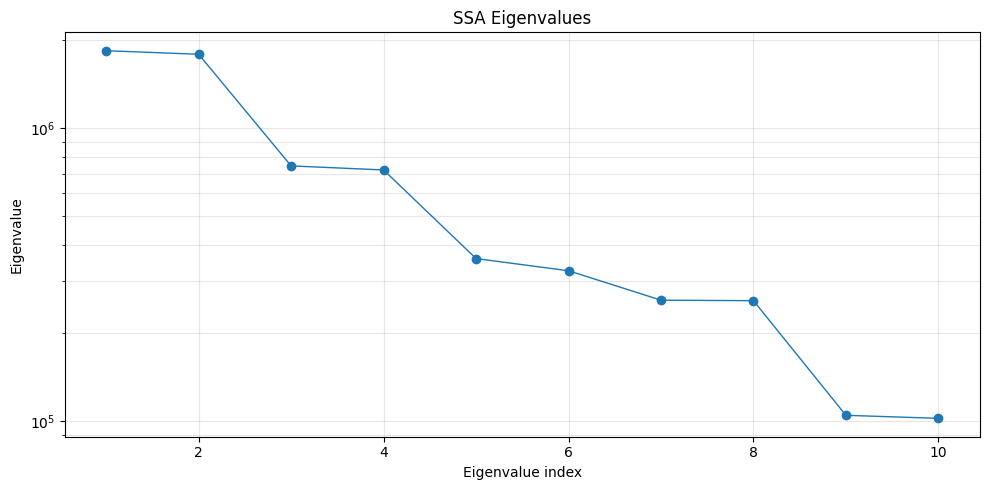

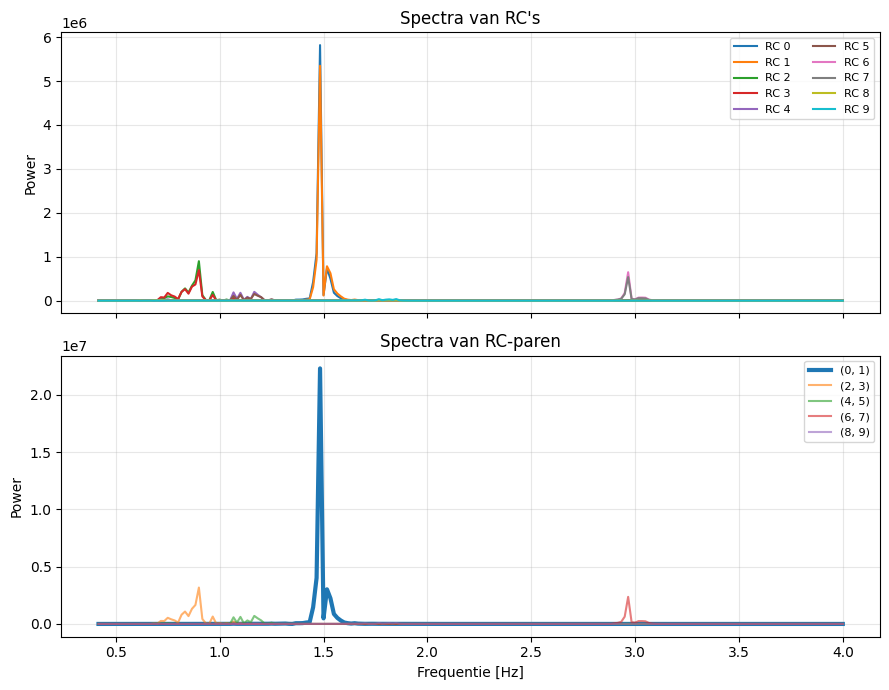

In [5]:
plot_ssa_overview(s, RCs, rc_pairs, pair_scores, fs, chosen_pair, pair_to_highlight=chosen_pair)



## CGO en HR visualisatie

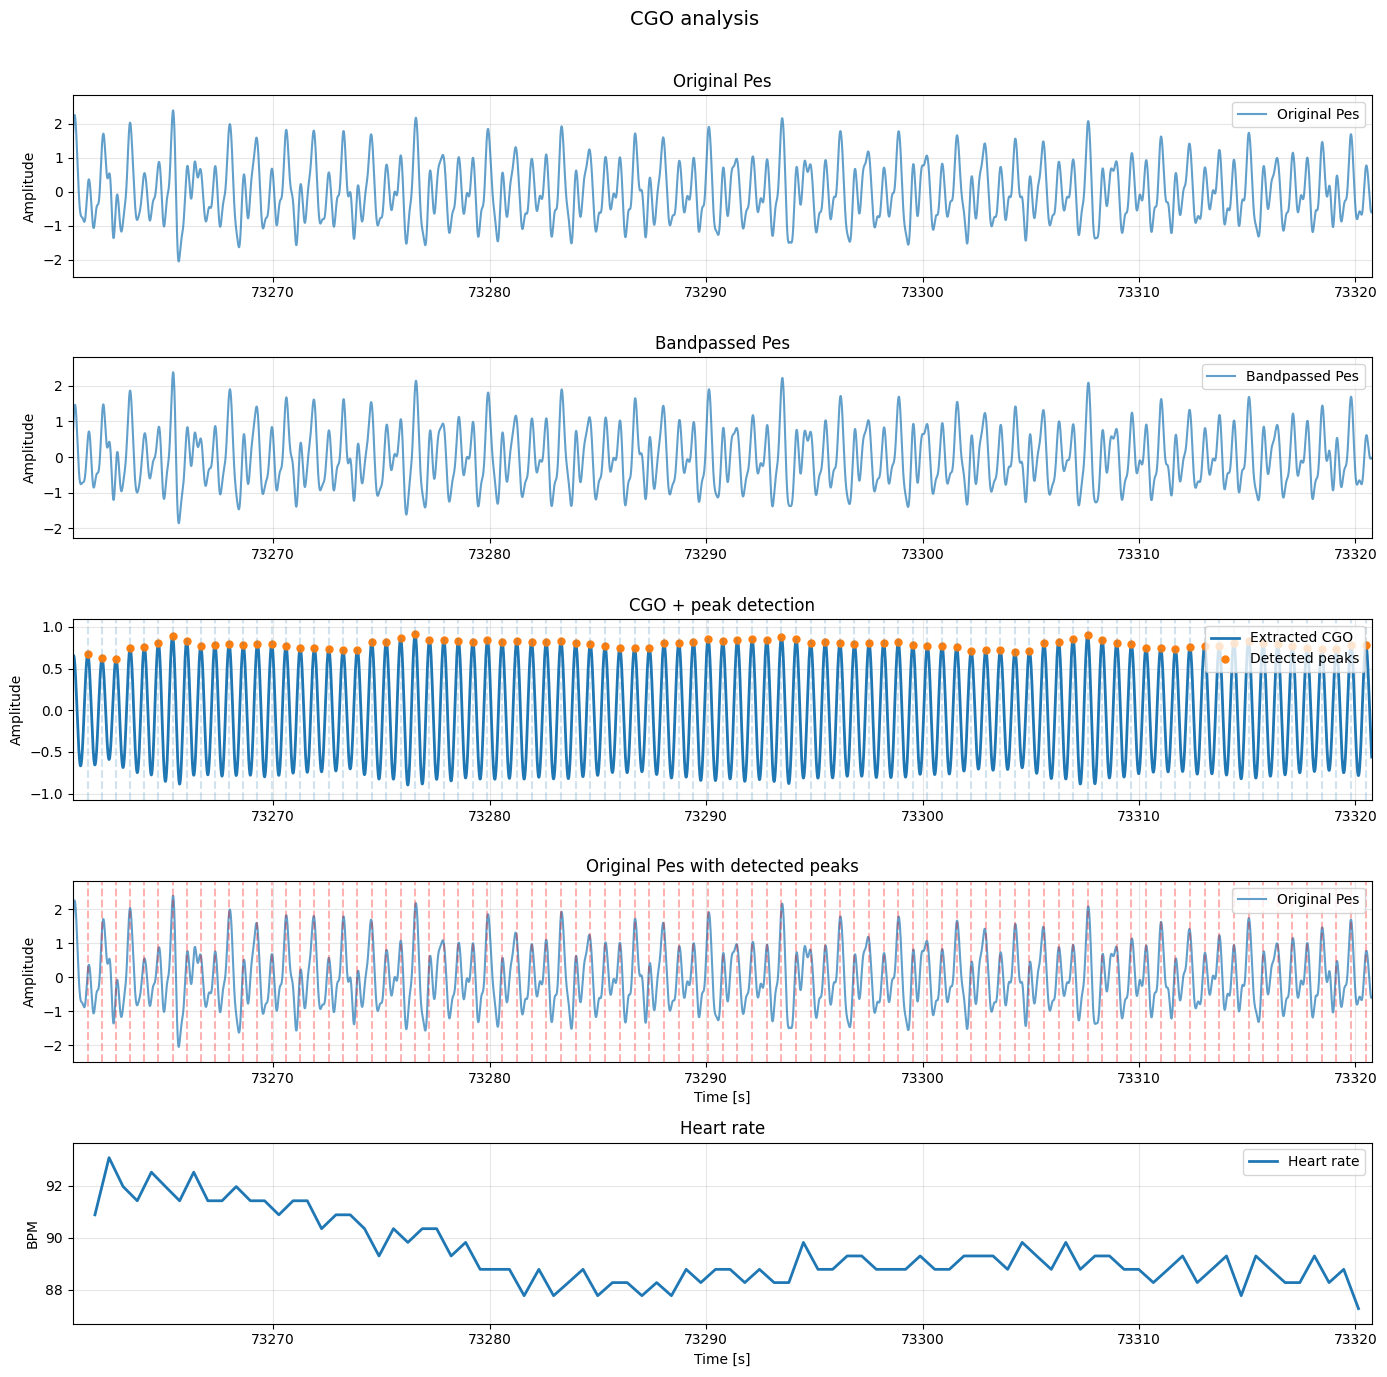

Gemiddelde hartslag uit pieken: 89.44 bpm
Mediaan hartslag uit pieken:    88.79 bpm


In [6]:
plot_cgo_analysis(
    time_window,
    pes_window,
    pes_bp,
    cgo,
    peaks,
    t_hr,
    hr,
)